# Titanic Data Analysis Project

## Import libraries

In [34]:
import pandas as pd
print("Pandas imported successfully!")

import numpy as np
print("NumPy imported successfully!")

import matplotlib as mpl
print("Matplotlib imported successfully!")

import matplotlib.pyplot as plt
print("Matplotlib.pyplot imported successfully!")

import seaborn as sns
print("SeaborN imported successfully!")

from datetime import datetime
print("DateTime imported successfully!")

import warnings
warnings.filterwarnings('ignore')

Pandas imported successfully!
NumPy imported successfully!
Matplotlib imported successfully!
Matplotlib.pyplot imported successfully!
SeaborN imported successfully!
DateTime imported successfully!


## Check versions

In [19]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 2.3.3
NumPy version: 2.4.0
Matplotlib version: 3.10.8
Seaborn version: 0.13.2


## Import Data

In [28]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')
print("✅ Data loaded successfully!")
print("Train Data : ")
print(f"Shape: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print("Test Data : ")
print(f"Shape: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print("\nFirst 5 rows of train.csv:")
display(train_df.head())
print("\nFirst 5 rows of test.csv:")
display(test_df.head())

✅ Data loaded successfully!
Train Data : 
Shape: 891 rows, 12 columns
Test Data : 
Shape: 418 rows, 11 columns

First 5 rows of train.csv:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



First 5 rows of test.csv:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Get basic information

In [29]:
print("📋 DATA INFORMATION:")
print("Training Data")
train_df.info()
print("Testing Data")
train_df.info()

📋 DATA INFORMATION:
Training Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Testing Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pas

## Finding number of Missing Values

In [9]:
print("🔍 MISSING VALUES:")
missing = train_df.isnull().sum()
print(missing[missing > 0])

🔍 MISSING VALUES:
Age         177
Cabin       687
Embarked      2
dtype: int64


## Visualize missing values

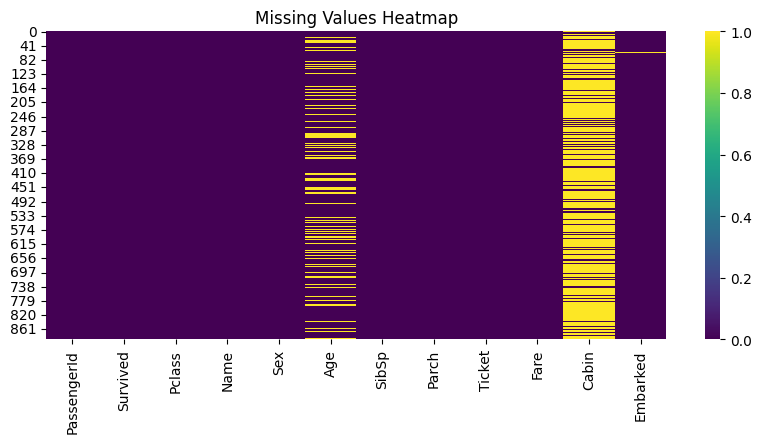

In [25]:
plt.figure(figsize=(10, 4))
sns.heatmap(train_df.isnull(), cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Percentage of missing values by column

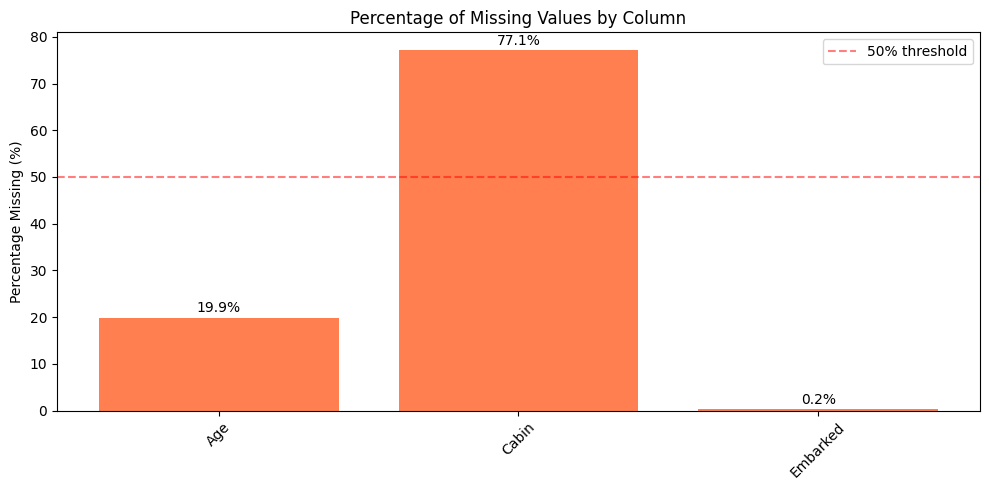

In [31]:
missing = train_df.isnull().sum() / len(train_df) * 100
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
bars = plt.bar(missing.index, missing.values, color='coral')
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage Missing (%)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.legend()
plt.tight_layout()
plt.show()

## Age Distribution of Passengers and it's Box plot

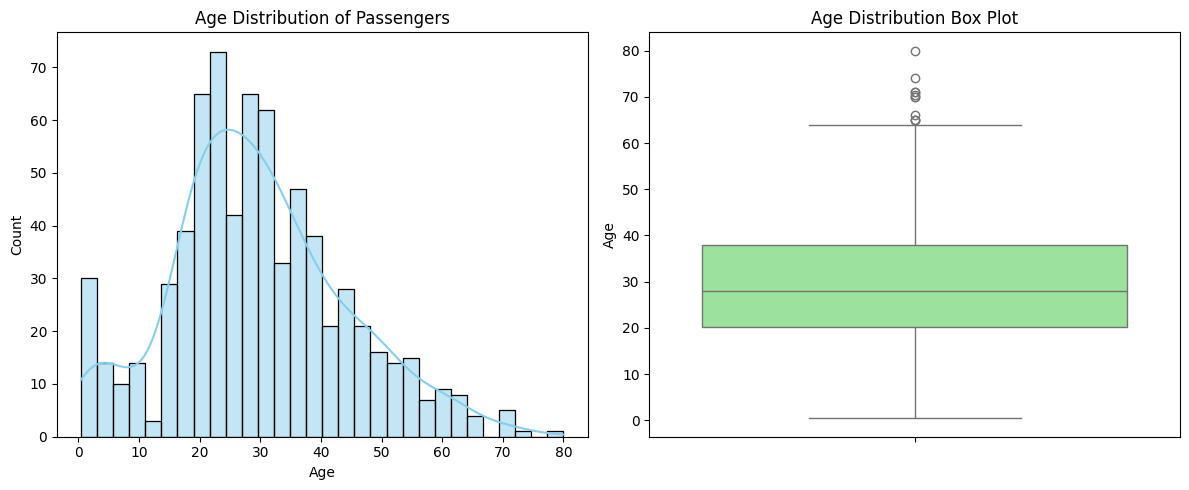

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='Age', bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, y='Age', color='lightgreen')
plt.title('Age Distribution Box Plot')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

## Pie and Bar charts of Gender Distribution

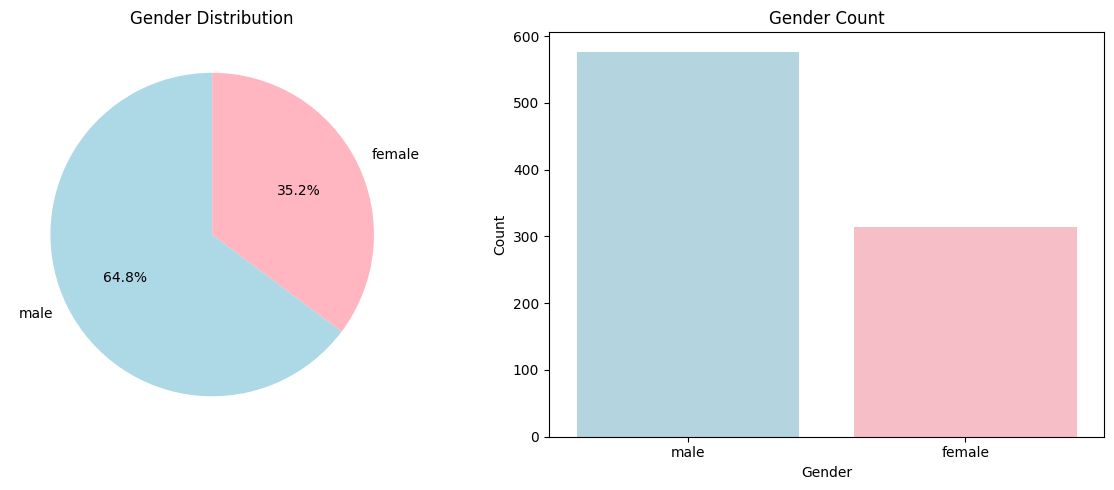

In [35]:
plt.figure(figsize=(12, 5))

# Pie Chart
plt.subplot(1, 2, 1)
gender_counts = train_df['Sex'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightpink'])
plt.title('Gender Distribution')

# Bar Chart
plt.subplot(1, 2, 2)
sns.countplot(data=train_df, x='Sex', palette=['lightblue', 'lightpink'])
plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Pie and Bar charts of Passenger Class Distribution

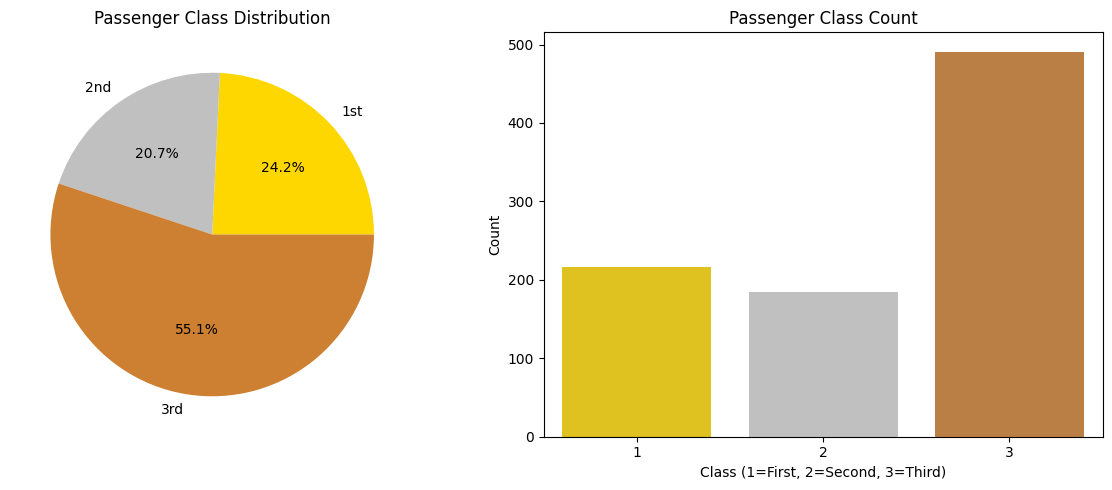

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
class_counts = train_df['Pclass'].value_counts().sort_index()
plt.pie(class_counts.values, labels=['1st', '2nd', '3rd'], 
        autopct='%1.1f%%', colors=['gold', 'silver', '#cd7f32'])
plt.title('Passenger Class Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=train_df, x='Pclass', palette=['gold', 'silver', '#cd7f32'])
plt.title('Passenger Class Count')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Overall Survival Rate on Titanic

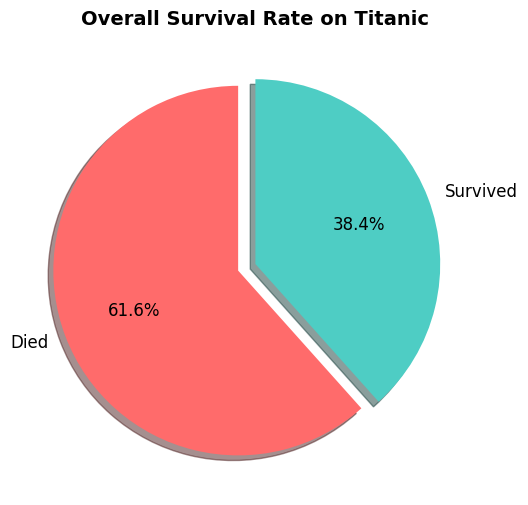

In [37]:
plt.figure(figsize=(10, 6))
survival_counts = train_df['Survived'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
explode = (0.1, 0)

plt.pie(survival_counts.values, labels=['Died', 'Survived'], 
        autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
        shadow=True, textprops={'fontsize': 12})
plt.title('Overall Survival Rate on Titanic', fontsize=14, fontweight='bold')
plt.show()

## Survival by Gender

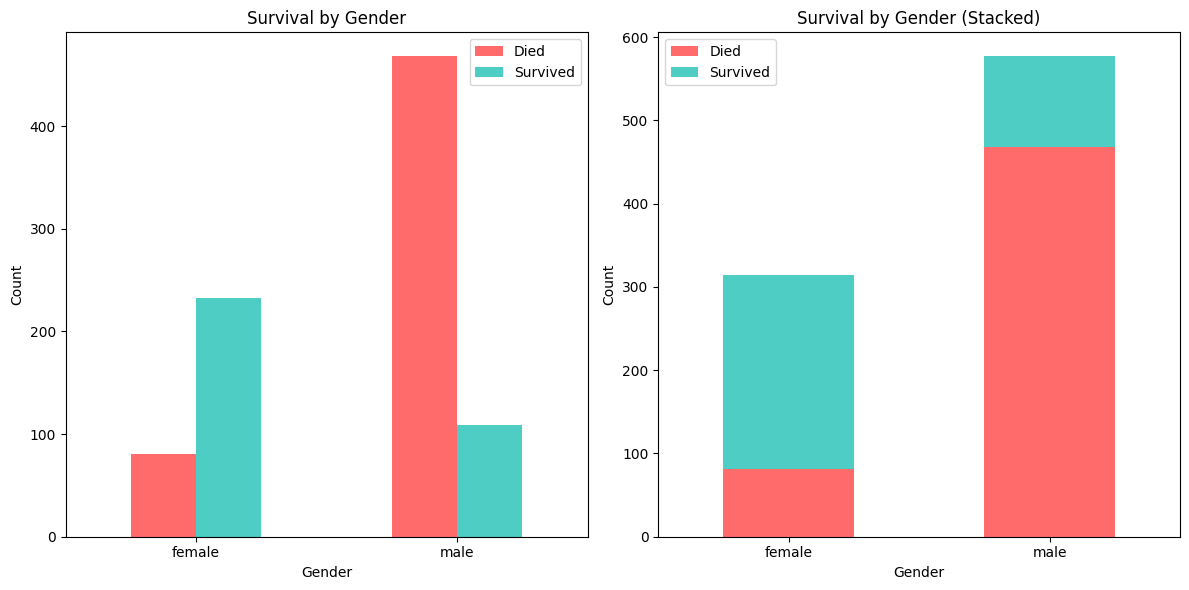

In [40]:
plt.figure(figsize=(12, 6))

survival_by_sex = pd.crosstab(train_df['Sex'], train_df['Survived'])

# First subplot (Grouped bar)
ax1 = plt.subplot(1, 2, 1)
survival_by_sex.plot(
    kind='bar',
    ax=ax1,
    color=['#ff6b6b', '#4ecdc4']
)
ax1.set_title('Survival by Gender')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')
ax1.legend(['Died', 'Survived'])
ax1.tick_params(axis='x', rotation=0)

# Second subplot (Stacked bar)
ax2 = plt.subplot(1, 2, 2)
survival_by_sex.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#ff6b6b', '#4ecdc4']
)
ax2.set_title('Survival by Gender (Stacked)')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Count')
ax2.legend(['Died', 'Survived'])
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Survival Rate by Age Group

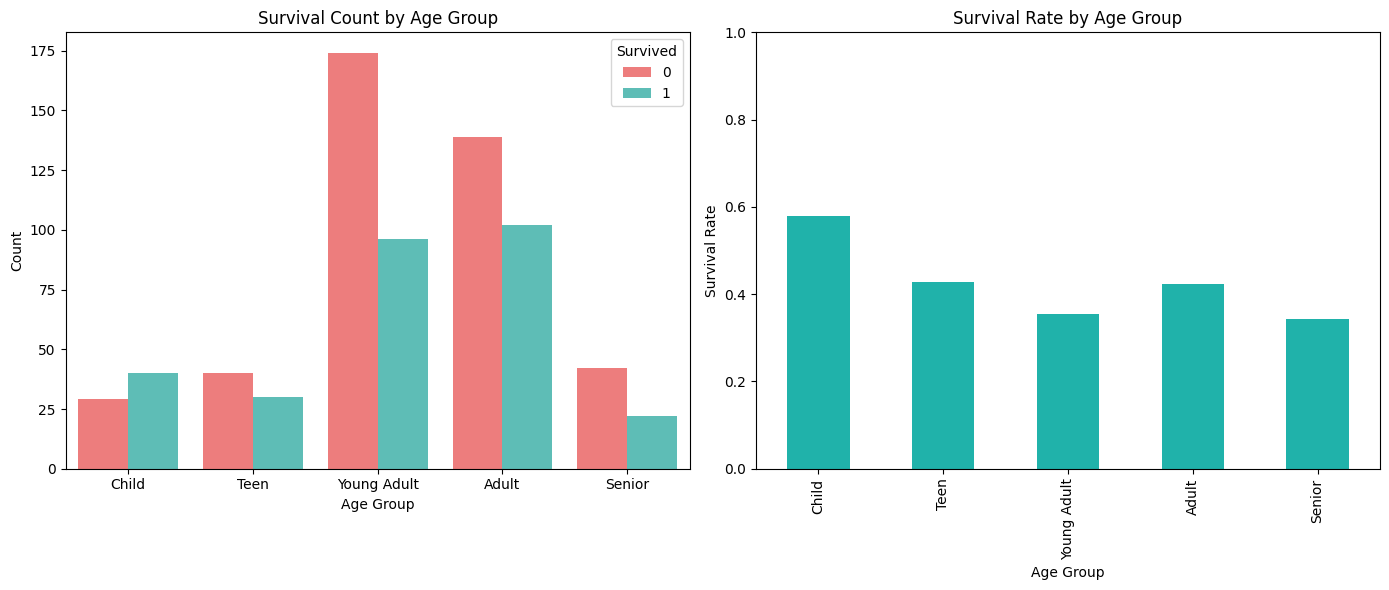

In [41]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], 
                             bins=[0, 12, 18, 30, 50, 80], 
                             labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='AgeGroup', hue='Survived', 
              palette=['#ff6b6b', '#4ecdc4'])
plt.title('Survival Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
age_survival = train_df.groupby('AgeGroup')['Survived'].mean()
age_survival.plot(kind='bar', color='lightseagreen')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Survival Rate by Family Size

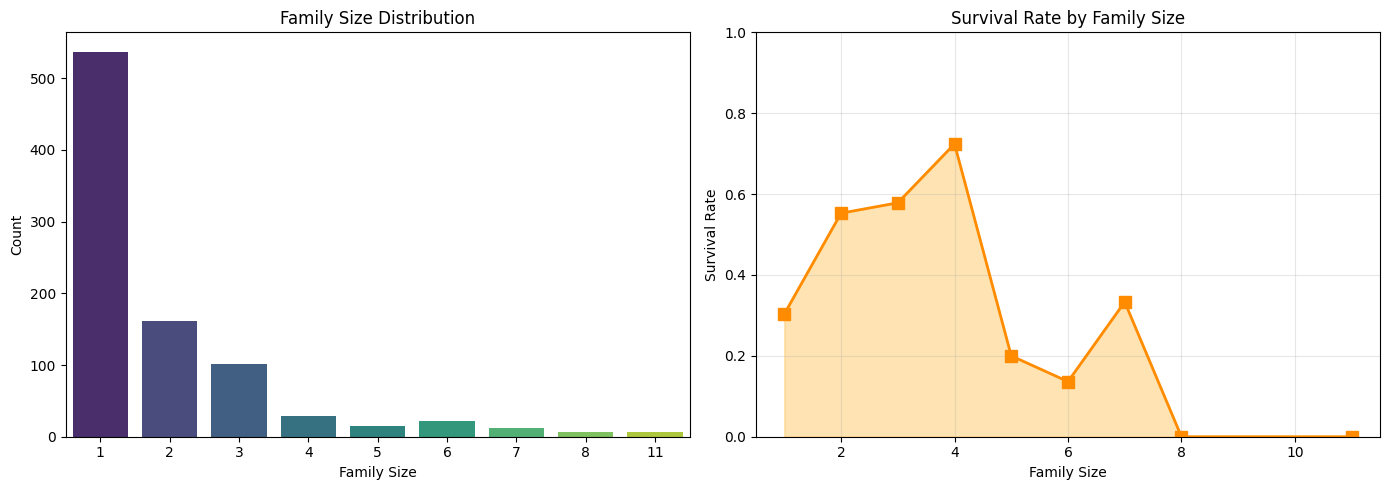

In [42]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='FamilySize', palette='viridis')
plt.title('Family Size Distribution')
plt.xlabel('Family Size')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
family_survival = train_df.groupby('FamilySize')['Survived'].mean()
plt.plot(family_survival.index, family_survival.values, 's-', 
         linewidth=2, markersize=8, color='darkorange')
plt.fill_between(family_survival.index, family_survival.values, alpha=0.3, color='orange')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Siblings/Spouses vs Parents/Children

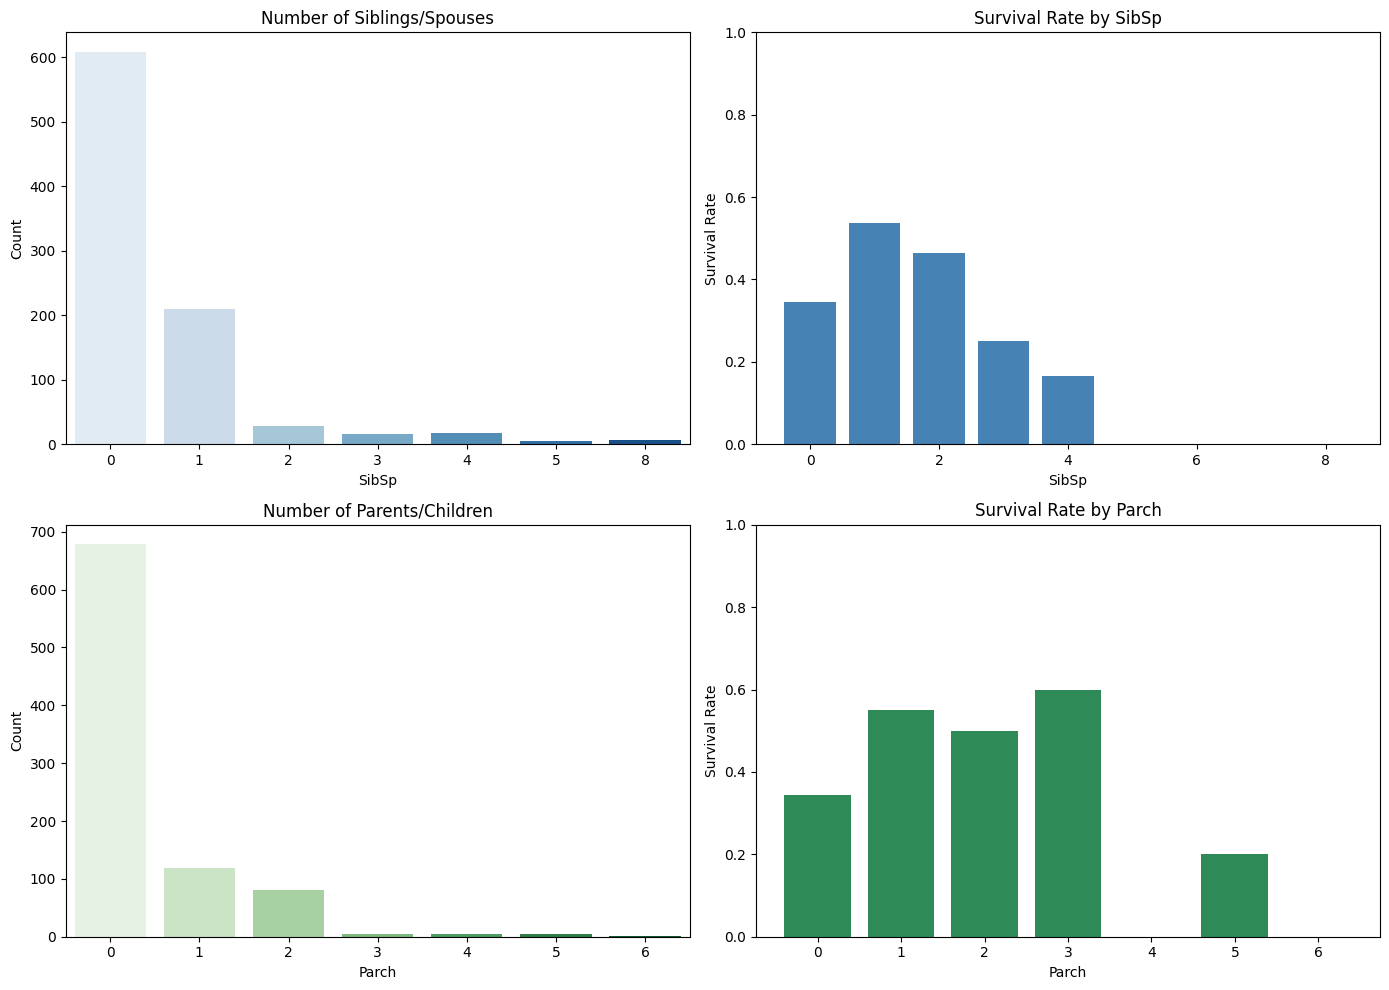

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SibSp Distribution
sns.countplot(data=train_df, x='SibSp', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Number of Siblings/Spouses')
axes[0, 0].set_xlabel('SibSp')
axes[0, 0].set_ylabel('Count')

# SibSp Survival
sibsp_survival = train_df.groupby('SibSp')['Survived'].mean()
axes[0, 1].bar(sibsp_survival.index, sibsp_survival.values, color='steelblue')
axes[0, 1].set_title('Survival Rate by SibSp')
axes[0, 1].set_xlabel('SibSp')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_ylim(0, 1)

# Parch Distribution
sns.countplot(data=train_df, x='Parch', ax=axes[1, 0], palette='Greens')
axes[1, 0].set_title('Number of Parents/Children')
axes[1, 0].set_xlabel('Parch')
axes[1, 0].set_ylabel('Count')

# Parch Survival
parch_survival = train_df.groupby('Parch')['Survived'].mean()
axes[1, 1].bar(parch_survival.index, parch_survival.values, color='seagreen')
axes[1, 1].set_title('Survival Rate by Parch')
axes[1, 1].set_xlabel('Parch')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Fare Distribution

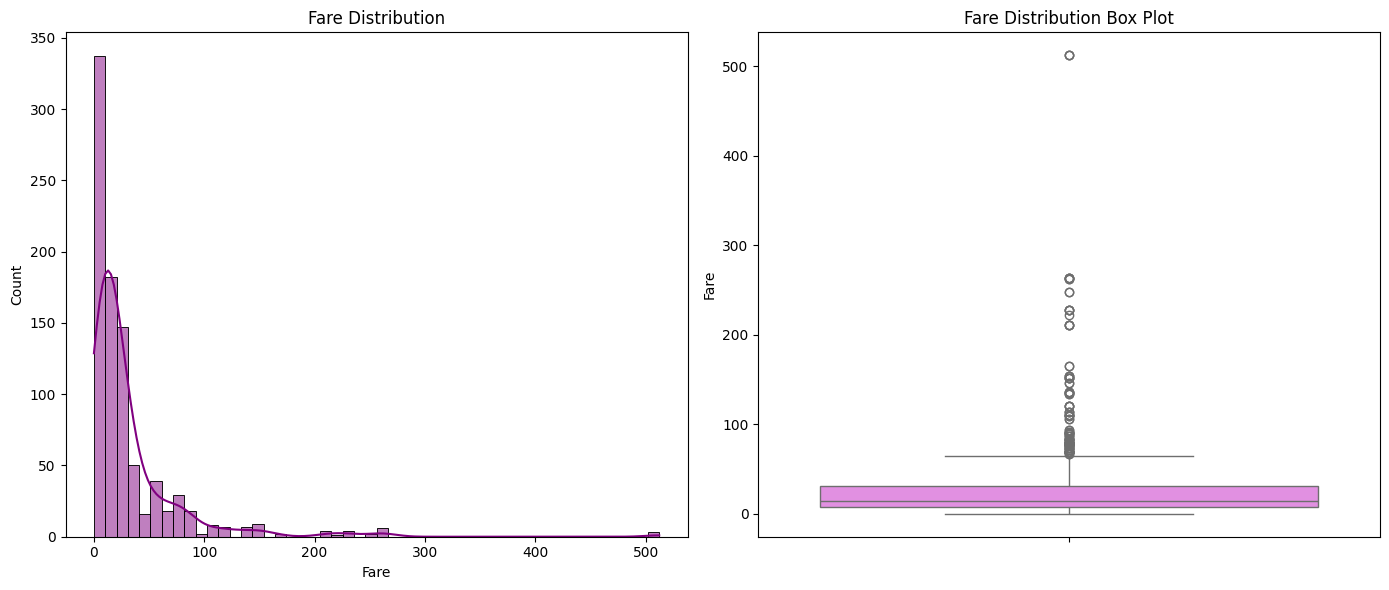

In [44]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='Fare', bins=50, kde=True, color='purple')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, y='Fare', color='violet')
plt.title('Fare Distribution Box Plot')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

## Fare Distribution by class

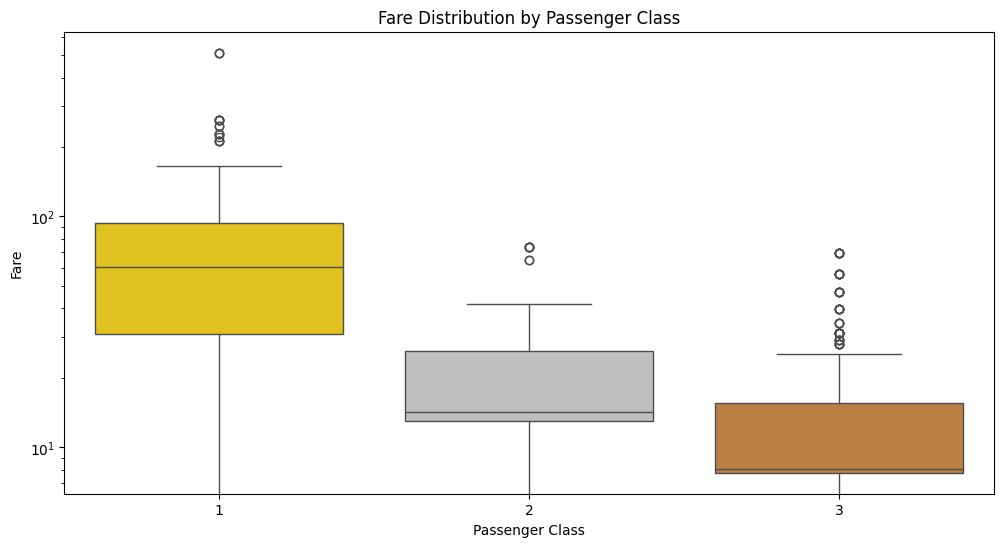

In [45]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='Pclass', y='Fare', palette=['gold', 'silver', '#cd7f32'])
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.yscale('log')  # Log scale for better visualization
plt.show()

## Embarkation port Analysis

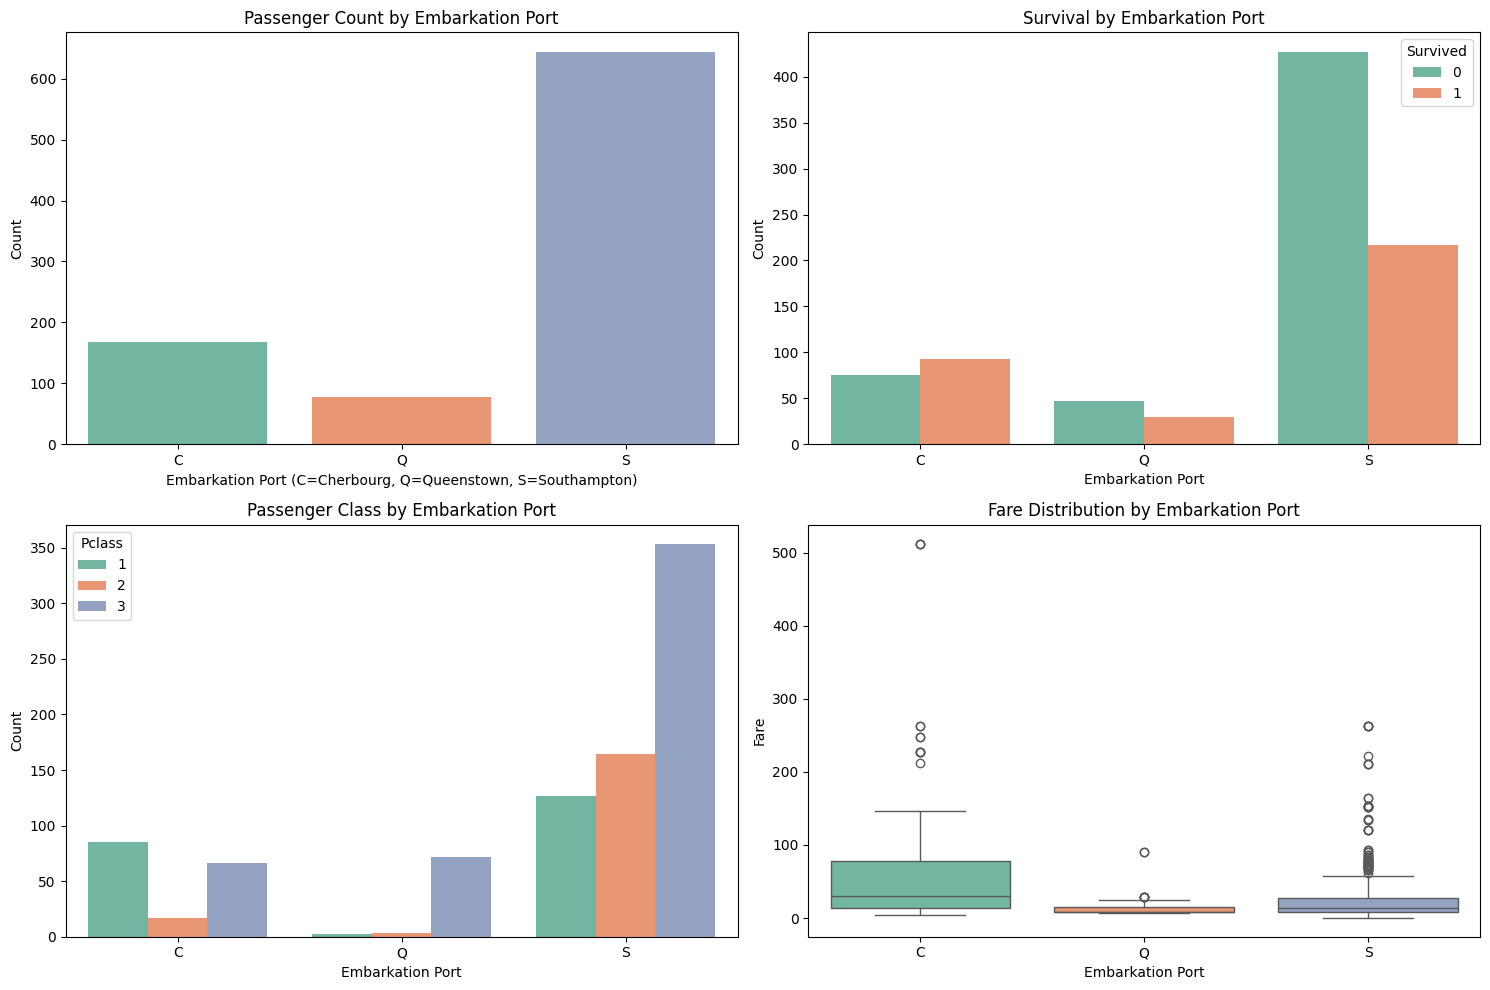

In [46]:
plt.figure(figsize=(15, 10))

# Count by Embarkation Port
plt.subplot(2, 2, 1)
sns.countplot(data=train_df, x='Embarked', palette='Set2', order=['C', 'Q', 'S'])
plt.title('Passenger Count by Embarkation Port')
plt.xlabel('Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')

# Survival by Embarkation
plt.subplot(2, 2, 2)
sns.countplot(data=train_df, x='Embarked', hue='Survived', palette='Set2', order=['C', 'Q', 'S'])
plt.title('Survival by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')

# Class by Embarkation
plt.subplot(2, 2, 3)
sns.countplot(data=train_df, x='Embarked', hue='Pclass', palette='Set2', order=['C', 'Q', 'S'])
plt.title('Passenger Class by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')

# Fare by Embarkation
plt.subplot(2, 2, 4)
sns.boxplot(data=train_df, x='Embarked', y='Fare', palette='Set2', order=['C', 'Q', 'S'])
plt.title('Fare Distribution by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

## Correlation Heatmap

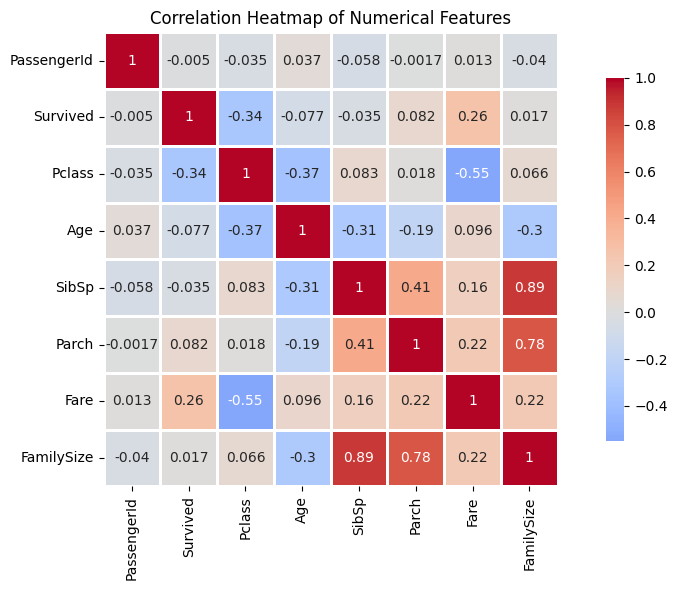

In [48]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Pair Plot (Scatter Matrix)

<Figure size 1200x1000 with 0 Axes>

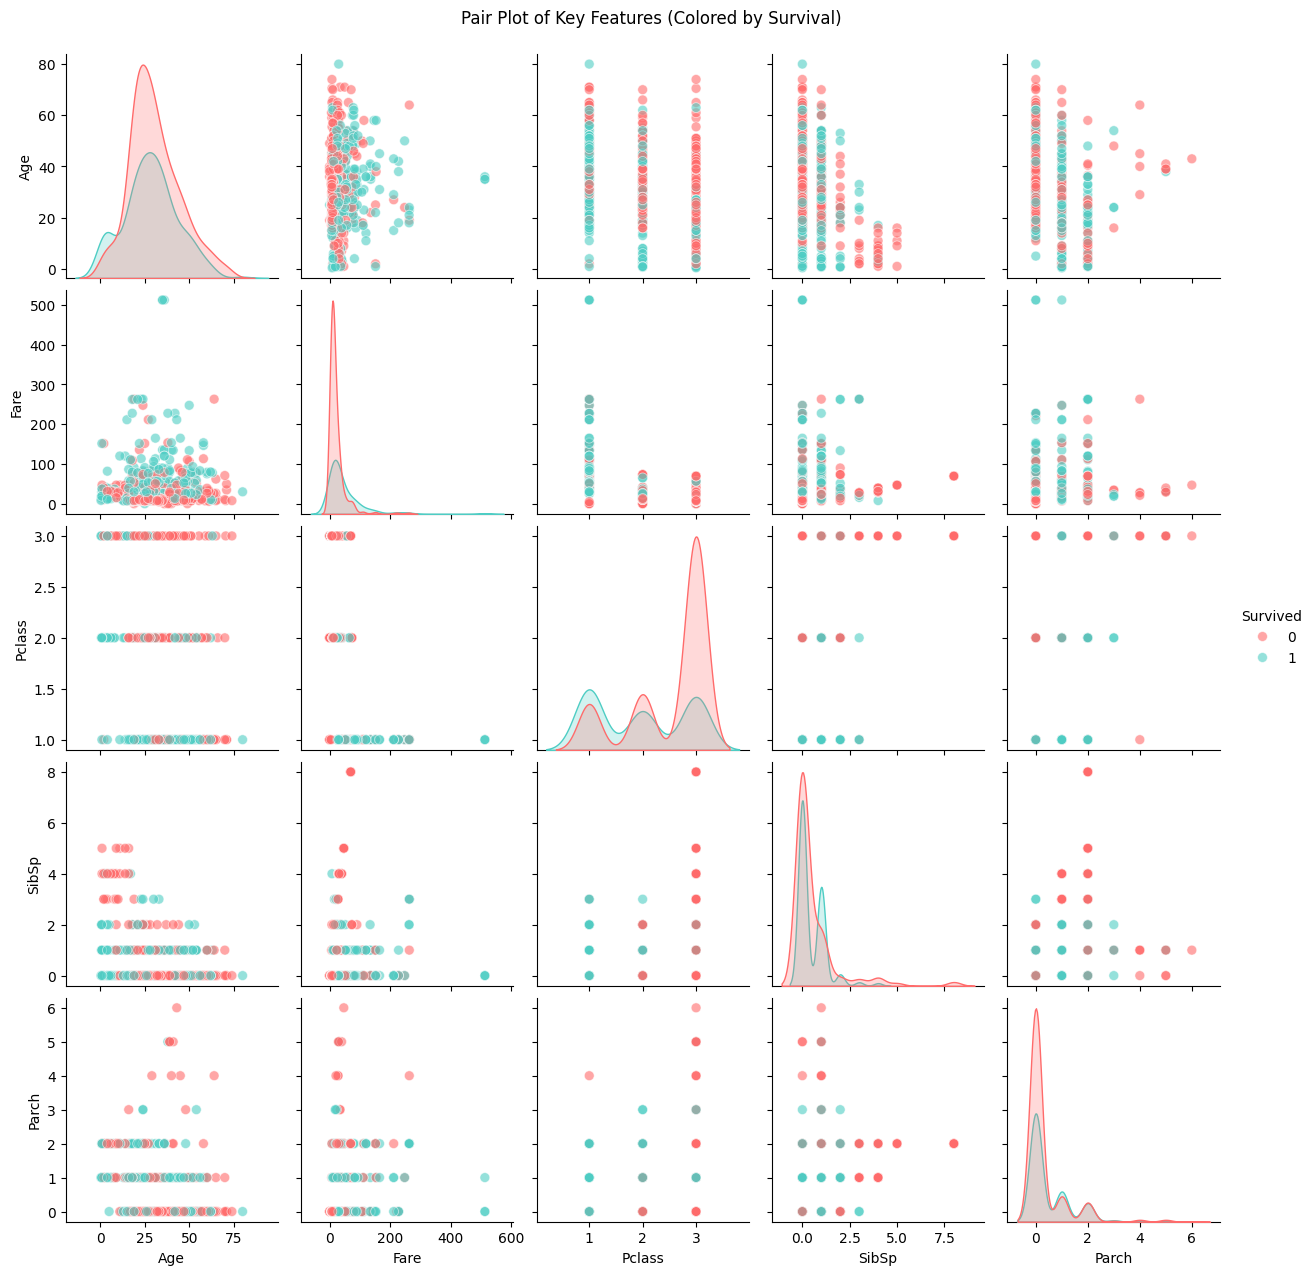

In [54]:
pairplot_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Survived']

plt.figure(figsize=(12, 10))
sns.pairplot(train_df[pairplot_cols], 
             hue='Survived', 
             palette={0: '#ff6b6b', 1: '#4ecdc4'},
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 50},
             diag_kws={'fill': True})
plt.suptitle('Pair Plot of Key Features (Colored by Survival)', y=1.02)
plt.show()

## Violin Plots (Distribution + Box Plot)

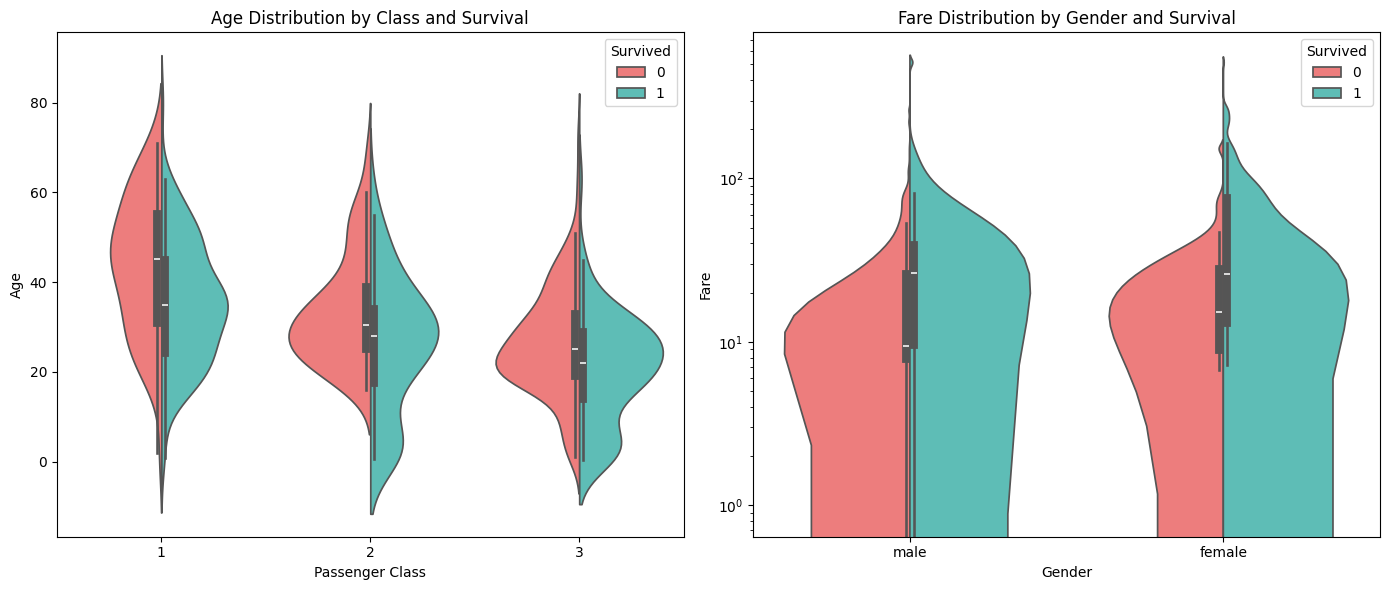

In [55]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.violinplot(data=train_df, x='Pclass', y='Age', hue='Survived', 
               split=True, palette={0: '#ff6b6b', 1: '#4ecdc4'})
plt.title('Age Distribution by Class and Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
sns.violinplot(data=train_df, x='Sex', y='Fare', hue='Survived',
               split=True, palette={0: '#ff6b6b', 1: '#4ecdc4'})
plt.title('Fare Distribution by Gender and Survival')
plt.xlabel('Gender')
plt.ylabel('Fare')
plt.yscale('log')

plt.tight_layout()
plt.show()

## Facet Grid (Multiple Subplots)

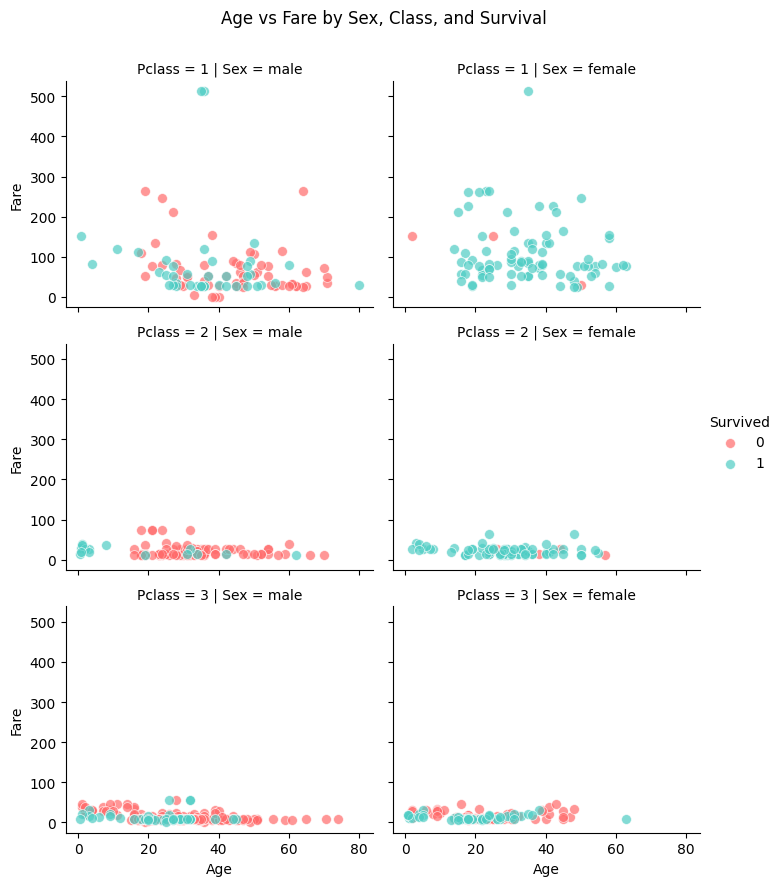

In [56]:
g = sns.FacetGrid(train_df, col='Sex', row='Pclass', hue='Survived', 
                  palette={0: '#ff6b6b', 1: '#4ecdc4'}, height=3, aspect=1.2)
g.map(sns.scatterplot, 'Age', 'Fare', alpha=0.7, s=50)
g.add_legend()
g.set_axis_labels('Age', 'Fare')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Age vs Fare by Sex, Class, and Survival')
plt.show()

## Swarm Plot (Categorical + Distribution)

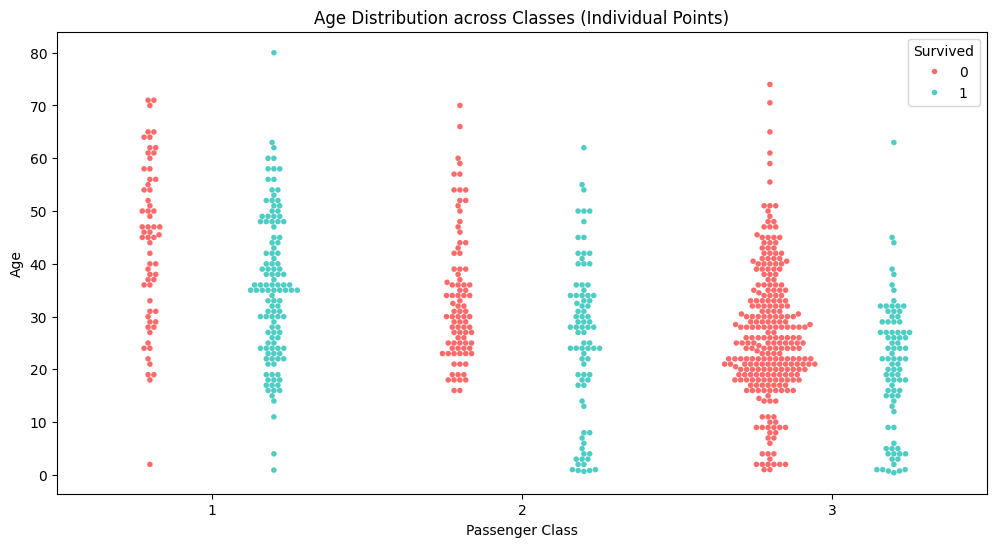

In [58]:
plt.figure(figsize=(12, 6))
sns.swarmplot(data=train_df, x='Pclass', y='Age', hue='Survived', 
              palette={0: '#ff6b6b', 1: '#4ecdc4'}, dodge=True, size=4)
plt.title('Age Distribution across Classes (Individual Points)')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(title='Survived')
plt.show()

## Survival Analysis Dashboard

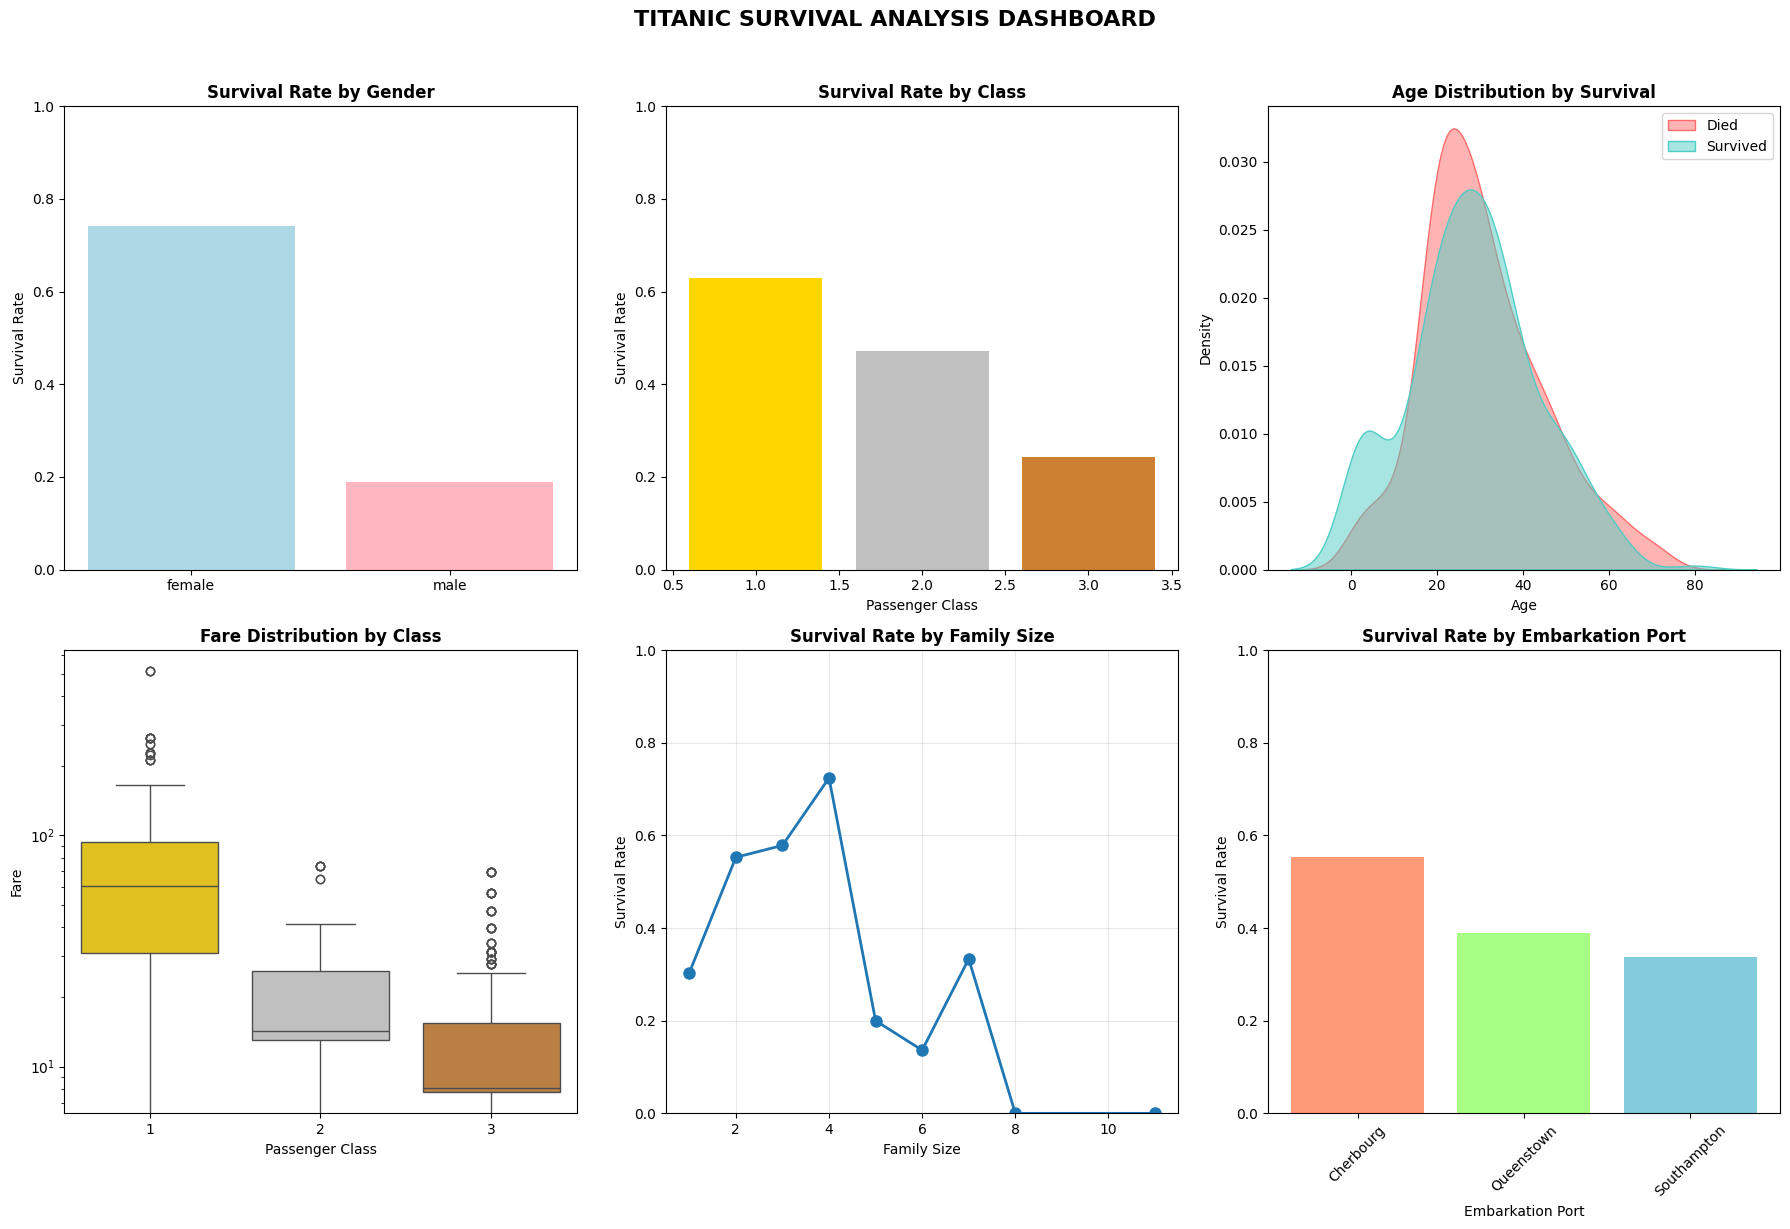

In [59]:
# Create a comprehensive dashboard
fig = plt.figure(figsize=(18, 12))

# 1. Survival by Gender
ax1 = plt.subplot(2, 3, 1)
gender_survival = train_df.groupby('Sex')['Survived'].mean()
ax1.bar(gender_survival.index, gender_survival.values, color=['lightblue', 'lightpink'])
ax1.set_title('Survival Rate by Gender', fontweight='bold')
ax1.set_ylabel('Survival Rate')
ax1.set_ylim(0, 1)

# 2. Survival by Class
ax2 = plt.subplot(2, 3, 2)
class_survival = train_df.groupby('Pclass')['Survived'].mean()
colors = ['gold', 'silver', '#cd7f32']
bars = ax2.bar(class_survival.index, class_survival.values, color=colors)
ax2.set_title('Survival Rate by Class', fontweight='bold')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Survival Rate')
ax2.set_ylim(0, 1)

# 3. Age Distribution by Survival
ax3 = plt.subplot(2, 3, 3)
sns.kdeplot(data=train_df[train_df['Survived']==0], x='Age', ax=ax3, 
            label='Died', color='#ff6b6b', fill=True, alpha=0.5)
sns.kdeplot(data=train_df[train_df['Survived']==1], x='Age', ax=ax3, 
            label='Survived', color='#4ecdc4', fill=True, alpha=0.5)
ax3.set_title('Age Distribution by Survival', fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Density')
ax3.legend()

# 4. Fare vs Class
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(data=train_df, x='Pclass', y='Fare', ax=ax4, palette=colors)
ax4.set_title('Fare Distribution by Class', fontweight='bold')
ax4.set_xlabel('Passenger Class')
ax4.set_ylabel('Fare')
ax4.set_yscale('log')

# 5. Family Size Survival
ax5 = plt.subplot(2, 3, 5)
family_survival = train_df.groupby('FamilySize')['Survived'].mean()
ax5.plot(family_survival.index, family_survival.values, 'o-', linewidth=2, markersize=8)
ax5.set_title('Survival Rate by Family Size', fontweight='bold')
ax5.set_xlabel('Family Size')
ax5.set_ylabel('Survival Rate')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3)

# 6. Embarkation Port Survival
ax6 = plt.subplot(2, 3, 6)
embark_survival = train_df.groupby('Embarked')['Survived'].mean()
ports = ['C', 'Q', 'S']
port_names = ['Cherbourg', 'Queenstown', 'Southampton']
ax6.bar(range(len(ports)), embark_survival.loc[ports].values, color=['#ff9a76', '#a7ff83', '#82ccdd'])
ax6.set_title('Survival Rate by Embarkation Port', fontweight='bold')
ax6.set_xlabel('Embarkation Port')
ax6.set_ylabel('Survival Rate')
ax6.set_xticks(range(len(ports)))
ax6.set_xticklabels(port_names, rotation=45)
ax6.set_ylim(0, 1)

plt.suptitle('TITANIC SURVIVAL ANALYSIS DASHBOARD', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()